In [8]:
"""
All required imports for the analysis pipeline.
Suppress warnings to maintain output clarity.
"""
import warnings
warnings.filterwarnings("ignore")

# Standard library
import numpy as np
from itertools import combinations

# Data manipulation and analysis
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm, ListedColormap
import seaborn as sns

# Statistical methods
from scipy.stats import t, spearmanr

# Machine learning: preprocessing & model selection
from sklearn.base import clone
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Linear models
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, SGDRegressor, HuberRegressor
)

# Tree-based models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    AdaBoostRegressor, HistGradientBoostingRegressor
)

# Instance-based and kernel methods
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Neural networks
from sklearn.neural_network import MLPRegressor

# Advanced boosting libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# SHAP for feature importance
import shap

print("✓ All libraries imported successfully")


✓ All libraries imported successfully


## 2. Data Loading and Exploration

In [9]:
# Load the raw dataset
df = pd.read_csv("Cogni-e-SpinDB 1.0.csv")
print(f"Raw dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")
df.head()

Raw dataset shape: (809, 20)
Columns: ['doi', 'polymer(s)', 'is_solvent_blend', 'solvent(s)', 'solvent_components', 'solution_concentration', 'solution_concentration_unit', 'needle_type', 'needle_diameter_g', 'collector_type', 'rotation_speed_rpm', 'voltage_kv', 'flow_rate_ml/h', 'tip_collector_distance_cm', 'temperature_c', 'humidity_%', 'was_formation_stable', 'fiber_diameter_nm', 'fiber_diameter_variation_nm', 'tail_observation']



,doi,polymer(s),is_solvent_blend,solvent(s),solvent_components,solution_concentration,solution_concentration_unit,needle_type,needle_diameter_g,collector_type,rotation_speed_rpm,voltage_kv,flow_rate_ml/h,tip_collector_distance_cm,temperature_c,humidity_%,was_formation_stable,fiber_diameter_nm,fiber_diameter_variation_nm,tail_observation
0,https://doi.org/10.1016/j.jafr.2019.100015,CA,False,ACETONE,"[{""solventName"": ""ACETONE"", ""weight"": null, ""w...",15.0,wt%,Single Needle,22.0,Flat,NaN,12.0,2.0,6.0,23.0,45,True,1346.0,812.0,True
1,https://doi.org/10.1016/j.jafr.2019.100015,CA,False,ACETONE,"[{""solventName"": ""ACETONE"", ""weight"": null, ""w...",12.0,wt%,Single Needle,22.0,Flat,NaN,16.0,2.0,6.0,23.0,45,True,488.0,221.0,False
2,https://doi.org/10.1016/j.jafr.2019.100015,CA,False,ACETONE,"[{""solventName"": ""ACETONE"", ""weight"": null, ""w...",15.0,wt%,Single Needle,22.0,Flat,NaN,16.0,2.0,10.0,23.0,45,True,823.0,519.0,False
3,https://doi.org/10.1016/j.jafr.2019.100015,CA,False,ACETONE,"[{""solventName"": ""ACETONE"", ""weight"": null, ""w...",9.0,wt%,Single Needle,22.0,Flat,NaN,12.0,2.0,6.0,23.0,45,True,452.0,236.0,False
4,https://doi.org/10.1016/j.jafr.2019.100015,CA,False,ACETONE,"[{""solventName"": ""ACETONE"", ""weight"": null, ""w...",12.0,wt%,Single Needle,22.0,Flat,NaN,12.0,2.0,10.0,23.0,45,True,801.0,382.0,False


## 3. Feature and Target Definition

In [10]:
# Define feature columns and target
feature_cols = [
    "solution_concentration",
    "voltage_kv",
    "flow_rate_ml/h",
    "tip_collector_distance_cm",
]

print(f"Features: {feature_cols}")
print(f"Target: fiber_diameter_nm")

Features: ['solution_concentration', 'voltage_kv', 'flow_rate_ml/h', 'tip_collector_distance_cm']
Target: fiber_diameter_nm


## 4. Data Preparation Function

In [11]:
def prepare_subset(polymer, doi_filter="https://doi.org/10.1007/s11814-009-0309-1"):
    """
    Extract and prepare dataset for a specific polymer from the database.
    
    Parameters
    ----------
    polymer : str
        Polymer type (e.g., 'PVA', 'PVDF')
    doi_filter : str
        DOI to filter experiments by publication source
    
    Returns
    -------
    X : pd.DataFrame
        Feature matrix
    y : pd.Series
        Target vector (fiber diameter in nm)
    """
    mask = (
        (df["polymer(s)"] == polymer) &
        (df["doi"] == doi_filter)
    )

    cols = feature_cols + ["fiber_diameter_nm"]
    subset = df.loc[mask, cols].copy()

    # Ensure numeric types
    for col in feature_cols + ["fiber_diameter_nm"]:
        subset[col] = pd.to_numeric(subset[col], errors="coerce")

    # Remove rows with missing values
    valid = subset[feature_cols].notna().all(axis=1) & subset["fiber_diameter_nm"].notna()

    X = subset.loc[valid, feature_cols].reset_index(drop=True)
    y = subset.loc[valid, "fiber_diameter_nm"].reset_index(drop=True)

    return X, y


# Prepare datasets for available polymers
datasets = {polymer: prepare_subset(polymer) for polymer in ["PVA"]}

# Create summary table
summary_df = pd.DataFrame([
    {
        "System": polymer,
        "Rows": len(X),
        "Mean diameter (nm)": y.mean(),
        "Std diameter (nm)": y.std(),
    }
    for polymer, (X, y) in datasets.items()
]).set_index("System")

pd.options.display.float_format = "{:.1f}".format
summary_df

,Rows,Mean diameter (nm),Std diameter (nm)
System,,,
PVA,96,259.0,34.6


## 5. Model Definitions


In [12]:
models = {
    # Linear models
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=42))
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01, random_state=42, max_iter=5000))
    ]),
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=5000))
    ]),
    "BayesianRidge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", BayesianRidge())
    ]),
    "SGDRegressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SGDRegressor(max_iter=2000, tol=1e-3, random_state=42))
    ]),
    "HuberRegressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", HuberRegressor(max_iter=500))
    ]),

    # Tree-based models
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, 
                            random_state=42, verbosity=0, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, 
                              n_jobs=-1, verbose=-1),

    # Kernel methods
    "SVR_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=1.0, epsilon=0.1))
    ]),
    "SVR_Poly": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="poly", degree=3, C=1.0, epsilon=0.1))
    ]),

    # Neural networks
    "MLP_64x32": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42))
    ]),
    "MLP_128x64": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42))
    ]),

    # Instance-based
    "KNN_5": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5, weights="uniform"))
    ]),
    "KNN_9_Distance": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=9, weights="distance"))
    ]),
}

# Map each model to its algorithmic family
model_family_map = {
    "LinearRegression": "Linear", "Ridge": "Linear", "Lasso": "Linear", 
    "ElasticNet": "Linear", "BayesianRidge": "Linear", "SGDRegressor": "Linear", 
    "HuberRegressor": "Linear",
    "DecisionTree": "Tree-based", "RandomForest": "Tree-based", "ExtraTrees": "Tree-based", 
    "GradientBoosting": "Boosting", "AdaBoost": "Boosting", "HistGradientBoosting": "Boosting", 
    "XGBoost": "Boosting", "LightGBM": "Boosting",
    "SVR_RBF": "Kernel", "SVR_Poly": "Kernel",
    "MLP_64x32": "Neural", "MLP_128x64": "Neural",
    "KNN_5": "Instance", "KNN_9_Distance": "Instance",
}

print(f"✓ Total models configured: {len(models)}")
print(f"  - Linear: 7 models")
print(f"  - Tree-based/Boosting: 8 models")
print(f"  - Kernel: 2 models")
print(f"  - Neural: 2 models")
print(f"  - Instance-based: 2 models")

✓ Total models configured: 21
  - Linear: 7 models
  - Tree-based/Boosting: 8 models
  - Kernel: 2 models
  - Neural: 2 models
  - Instance-based: 2 models


## 6. Cross-Validation Setup

In [13]:
def summarize_scores(scores):
    """Compute mean and standard deviation of cross-validation scores."""
    scores = np.asarray(scores, dtype=float)
    return float(scores.mean()), float(scores.std(ddof=1))


# Setup 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Scoring metrics: R² and MAE
scoring = {
    "r2": "r2",
    "neg_mae": "neg_mean_absolute_error"
}

print(f"✓ Cross-validation: 5-fold")
print(f"✓ Scoring metrics: R² and Mean Absolute Error (MAE)")

✓ Cross-validation: 5-fold
✓ Scoring metrics: R² and Mean Absolute Error (MAE)


## 7. Model Evaluation Function

In [14]:
def evaluate_models(X, y):
    """
    Evaluate all models using cross-validation.
    
    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix
    y : pd.Series
        Target vector
    
    Returns
    -------
    dict
        Dictionary with R² and MAE statistics for each model
    """
    dataset_results = {}
    for name, model in models.items():
        cv_res = cross_validate(model, X, y, cv=cv, scoring=scoring)
        r2_scores = cv_res["test_r2"]
        mae_scores = -cv_res["test_neg_mae"]
        dataset_results[name] = {
            "R2": summarize_scores(r2_scores),
            "MAE": summarize_scores(mae_scores)
        }
    return dataset_results


print("✓ Evaluation function ready")

✓ Evaluation function ready


## 8. Execute Cross-Validation

In [15]:
print("Starting cross-validation for all models...")

records = []
for label, (X_set, y_set) in datasets.items():
    model_metrics = evaluate_models(X_set, y_set)
    for name, metrics in model_metrics.items():
        r2_m, r2_s = metrics["R2"]
        mae_m, mae_s = metrics["MAE"]
        records.append({
            "System": label,
            "Model": name,
            "AlgorithmFamily": model_family_map.get(name, "Other"),
            "R2_mean": r2_m,
            "R2_std": r2_s,
            "MAE_mean": mae_m,
            "MAE_std": mae_s
        })

results_df = pd.DataFrame(records).sort_values(["System", "R2_mean"], ascending=[True, False])
print(f"✓ Evaluation complete. {len(results_df)} results stored.")

Starting cross-validation for all models...


✓ Evaluation complete. 21 results stored.


## 9. Results Summary Table

In [16]:
pd.options.display.float_format = "{:.3f}".format

def fmt_mean_std(mean_val, std_val):
    """Format mean ± std as a string."""
    return f"{mean_val:.3f} ± {std_val:.3f}"


report_df = results_df[["System", "Model", "AlgorithmFamily"]].copy()
report_df["R² (mean ± std)"] = [
    fmt_mean_std(m, s) for m, s in zip(results_df["R2_mean"], results_df["R2_std"])
]
report_df["MAE (mean ± std)"] = [
    fmt_mean_std(m, s) for m, s in zip(results_df["MAE_mean"], results_df["MAE_std"])
]

print("All 22 Models - Cross-Validation Results (5-Fold)\n")
report_df

All 22 Models - Cross-Validation Results (5-Fold)



,System,Model,AlgorithmFamily,R² (mean ± std),MAE (mean ± std)
10,PVA,GradientBoosting,Boosting,0.884 ± 0.062,8.216 ± 2.734
13,PVA,XGBoost,Boosting,0.869 ± 0.057,8.428 ± 1.676
8,PVA,RandomForest,Tree-based,0.816 ± 0.044,10.513 ± 1.962
9,PVA,ExtraTrees,Tree-based,0.779 ± 0.080,10.707 ± 1.359
11,PVA,AdaBoost,Boosting,0.733 ± 0.060,12.892 ± 2.475
19,PVA,KNN_5,Instance,0.726 ± 0.093,12.603 ± 2.858
14,PVA,LightGBM,Boosting,0.630 ± 0.182,15.333 ± 3.618
20,PVA,KNN_9_Distance,Instance,0.627 ± 0.126,15.101 ± 3.716
12,PVA,HistGradientBoosting,Boosting,0.591 ± 0.154,16.266 ± 2.945
7,PVA,DecisionTree,Tree-based,0.579 ± 0.267,13.318 ± 1.877


## 10. Top Performing Models

In [17]:
top_per_system = (
    results_df
    .sort_values(["System", "R2_mean"], ascending=[True, False])
    .groupby("System", as_index=False)
    .head(5)[["System", "Model", "AlgorithmFamily", "R2_mean", "MAE_mean"]]
    .reset_index(drop=True)
)

top_per_system.columns = ["System", "Model", "Family", "Top R²", "Top MAE"]
print("Top 5 Models by R² Score\n")
top_per_system

Top 5 Models by R² Score



,System,Model,Family,Top R²,Top MAE
0,PVA,GradientBoosting,Boosting,0.884,8.216
1,PVA,XGBoost,Boosting,0.869,8.428
2,PVA,RandomForest,Tree-based,0.816,10.513
3,PVA,ExtraTrees,Tree-based,0.779,10.707
4,PVA,AdaBoost,Boosting,0.733,12.892


## 11. Model Performance Radar Chart

Visualization of normalized $R^2$ performance across all 22 models, grouped by algorithmic family.

In [18]:
# Aesthetic names for display
pretty_names = {
    "LinearRegression": "Linear", "Ridge": "Ridge", "Lasso": "Lasso",
    "ElasticNet": "Elastic Net", "BayesianRidge": "Bayesian Ridge", 
    "HuberRegressor": "Huber", "SGDRegressor": "SGD",
    "DecisionTree": "Decision Tree", "RandomForest": "Random Forest", 
    "ExtraTrees": "Extra Trees", "GradientBoosting": "GradBoost",
    "AdaBoost": "AdaBoost", "HistGradientBoosting": "Hist-GB", 
    "XGBoost": "XGBoost", "LightGBM": "LightGBM",
    "SVR_RBF": "SVR (RBF)", "SVR_Poly": "SVR (Poly)",
    "MLP_128x64": "MLP (128×64)", "MLP_64x32": "MLP (64×32)",
    "KNN_5": "KNN (k=5)", "KNN_9_Distance": "KNN (k=9)",
}

# Family-based styling (colorblind-friendly, publication-safe)
family_config = {
    "Linear": {"color": "#4E79A7", "marker": "o"},
    "Tree-based": {"color": "#59A14F", "marker": "s"},
    "Boosting": {"color": "#E15759", "marker": "^"},
    "Kernel": {"color": "#9C755F", "marker": "D"},
    "Neural": {"color": "#B07AA1", "marker": "v"},
    "Instance": {"color": "#76B7B2", "marker": "P"},
}

# Build color and marker mappings
model_colors = {}
model_markers = {}
for model_name, family in model_family_map.items():
    if family in family_config:
        model_colors[model_name] = family_config[family]["color"]
        model_markers[model_name] = family_config[family]["marker"]

print("✓ Visualization styling configured")

✓ Visualization styling configured


In [19]:
# Prepare radar chart data
ordered_models = list(models.keys())
n = len(ordered_models)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

# Normalize R² values for radar visualization
col = "R2_mean"
lo, hi = results_df[col].min(), results_df[col].max()

if hi != lo:
    normalized_values = (results_df[col] - lo) / (hi - lo)
else:
    normalized_values = np.full(len(results_df), 0.5)

temp_df = results_df.copy()
temp_df["Normalized"] = normalized_values
values = temp_df.set_index("Model").reindex(ordered_models)["Normalized"].fillna(0).tolist()
values += values[:1]

print(f"R² range: [{lo:.3f}, {hi:.3f}]")
print("✓ Radar data prepared")

R² range: [-0.657, 0.884]
✓ Radar data prepared


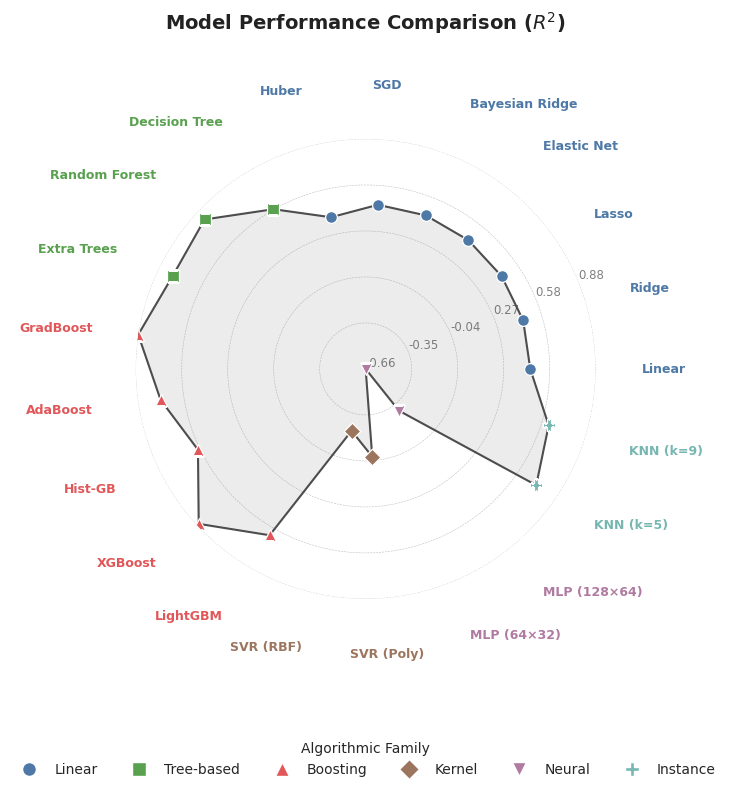

✓ Radar chart saved


In [20]:
# Create radar chart
sns.set_theme(style="white", context="paper")
fig = plt.figure(figsize=(12, 10))
ax = fig.add_axes([0.28, 0.27, 0.44, 0.46], polar=True)

# Background grid rings
for r in np.linspace(0, 1, 6):
    ax.plot(np.linspace(0, 2 * np.pi, 300), [r] * 300,
            color="grey", linewidth=0.4, linestyle="--", alpha=0.5)

# Radar fill and outline
ax.fill(angles, values, alpha=0.10, color="#4d4d4d")
ax.plot(angles, values, linewidth=1.5, color="#4d4d4d", zorder=3)

# Plot individual model points
for i, model in enumerate(ordered_models):
    color = model_colors.get(model, "#888888")
    marker = model_markers.get(model, "o")
    ax.scatter(angles[i], values[i], s=72, color=color, marker=marker, zorder=5,
               edgecolors="white", linewidths=0.9)

# Add model labels
for angle, model in zip(angles[:-1], ordered_models):
    color = model_colors.get(model, "#888888")
    label = pretty_names.get(model, model)
    x = np.cos(angle)
    y = np.sin(angle)
    ha = "left" if x > 0.2 else ("right" if x < -0.2 else "center")
    offset = 1.20 if abs(y) < 0.65 else 1.24
    ax.text(angle, offset, label, ha=ha, va="center", fontsize=9,
            color=color, fontweight="semibold", rotation=0, rotation_mode="anchor")

# Configure radial axis
ax.set_ylim(0, 1)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f"{lo + i*(hi-lo)/5:.2f}" for i in range(6)],
                     fontsize=8.5, color="grey")
ax.set_xticks(angles[:-1])
ax.set_xticklabels([])
ax.grid(False)
ax.spines["polar"].set_visible(False)

# Title
fig.text(0.5, 0.84, "Model Performance Comparison ($R^2$)",
         ha="center", fontsize=14, fontweight="bold", color="#222222")

# Legend
legend_handles = [
    Line2D([0], [0], marker=cfg["marker"], color="none", label=family,
           markerfacecolor=cfg["color"], markeredgecolor="white", markersize=10)
    for family, cfg in family_config.items()
]

fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, 0.08),
           ncol=6, fontsize=10, frameon=False, title="Algorithmic Family", title_fontsize=10)

plt.savefig("fig_model_comparison_radar.pdf", dpi=300, bbox_inches="tight", format="pdf")
plt.savefig("fig_model_comparison_radar.png", dpi=300, bbox_inches="tight", format="png")
plt.show()

print("✓ Radar chart saved")

## 12. SHAP Feature Importance Analysis

We compute SHAP values across all models to assess feature importance consistency and ranking agreement.

In [21]:
# Select dataset for SHAP analysis
system_for_shap = list(datasets.keys())[0]
X_shap, y_shap = datasets[system_for_shap]

# Use top-performing models for efficiency
ranked = results_df[results_df["System"] == system_for_shap].sort_values("R2_mean", ascending=False)
selected_models = ranked["Model"].tolist()

print(f"Dataset: {system_for_shap}")
print(f"Models for SHAP analysis: {len(selected_models)}")
print(f"Feature matrix shape: {X_shap.shape}")
print(f"Target vector shape: {y_shap.shape}\n")
print(f"Selected models: {selected_models}")

# Create background dataset for SHAP explainer
background = shap.utils.sample(X_shap, min(40, len(X_shap)), random_state=42)
print(f"Background size: {background.shape[0]}")


Dataset: PVA
Models for SHAP analysis: 21
Feature matrix shape: (96, 4)
Target vector shape: (96,)

Selected models: ['GradientBoosting', 'XGBoost', 'RandomForest', 'ExtraTrees', 'AdaBoost', 'KNN_5', 'LightGBM', 'KNN_9_Distance', 'HistGradientBoosting', 'DecisionTree', 'BayesianRidge', 'Ridge', 'ElasticNet', 'SGDRegressor', 'Lasso', 'LinearRegression', 'HuberRegressor', 'SVR_Poly', 'SVR_RBF', 'MLP_128x64', 'MLP_64x32']
Background size: 40


## 13. SHAP Ranking Computation

In [22]:
print("Computing SHAP values for all selected models...")

ranking_records = []

for idx, model_name in enumerate(selected_models, 1):
    # Clone and fit model
    estimator = clone(models[model_name])
    estimator.fit(X_shap, y_shap)

    # Compute SHAP values
    explainer = shap.Explainer(estimator.predict, background)
    shap_values = explainer(X_shap)

    # Compute mean absolute SHAP values
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    importances = pd.Series(mean_abs_shap, index=X_shap.columns).sort_values(ascending=False)

    # Record rankings
    for rank, (feature, value) in enumerate(importances.items(), start=1):
        ranking_records.append({
            "System": system_for_shap,
            "Model": model_name,
            "AlgorithmFamily": model_family_map.get(model_name, "Other"),
            "Feature": feature,
            "MeanAbsSHAP": value,
            "Rank": rank
        })
    
    if (idx % 5 == 0) or (idx == len(selected_models)):
        print(f"  Processed {idx}/{len(selected_models)} models")

shap_rank_df = pd.DataFrame(ranking_records)
rank_matrix = shap_rank_df.pivot_table(index="Feature", columns="Model", values="Rank")

print(f"✓ SHAP analysis complete")
print(f"  {len(shap_rank_df)} feature rankings computed")


Computing SHAP values for all selected models...


ExactExplainer explainer: 97it [00:23,  4.00it/s]                        
ExactExplainer explainer: 97it [00:39,  1.79it/s]                        
ExactExplainer explainer: 97it [00:46,  1.62it/s]                        


  Processed 5/21 models
  Processed 10/21 models
  Processed 15/21 models
  Processed 20/21 models
  Processed 21/21 models
✓ SHAP analysis complete
  84 feature rankings computed


## 14. SHAP Ranking Consistency Metrics

In [23]:
# Compute pairwise Spearman rank correlations
pairwise_records = []
for m1, m2 in combinations(rank_matrix.columns, 2):
    rho, pval = spearmanr(rank_matrix[m1], rank_matrix[m2])
    pairwise_records.append({
        "ModelA": m1,
        "ModelB": m2,
        "SpearmanRho": rho,
        "PValue": pval
    })

pairwise_consistency_df = pd.DataFrame(pairwise_records).sort_values("SpearmanRho", ascending=False)
overall_consistency = pairwise_consistency_df["SpearmanRho"].mean()

# Consensus ranking
consensus_rank = (
    shap_rank_df
    .groupby("Feature", as_index=False)["Rank"]
    .agg(MeanRank="mean", SDRank=lambda s: s.std(ddof=0))
    .sort_values("MeanRank")
)

# Top-1 frequency
top1_counts = (
    shap_rank_df[shap_rank_df["Rank"] == 1]
    .groupby("Feature")
    .size()
    .rename("Top1Count")
    .reset_index()
    .sort_values("Top1Count", ascending=False)
)

print(f"Pairwise Spearman ρ: Mean = {overall_consistency:.3f}")
print(f"  Range: [{pairwise_consistency_df['SpearmanRho'].min():.3f}, "
      f"{pairwise_consistency_df['SpearmanRho'].max():.3f}]")
print()
print("SHAP Ranking Consensus\n")
print(consensus_rank)
print()
print("Top-1 Feature Frequency\n")
print(top1_counts)

Pairwise Spearman ρ: Mean = 0.584
  Range: [0.200, 1.000]

SHAP Ranking Consensus

                     Feature  MeanRank  SDRank
1     solution_concentration     1.000   0.000
0             flow_rate_ml/h     2.905   0.921
3                 voltage_kv     3.000   0.926
2  tip_collector_distance_cm     3.095   0.526

Top-1 Feature Frequency

                  Feature  Top1Count
0  solution_concentration         21


## 15. Top-K Feature Set Agreement

In [24]:
# Compute top-k agreement
n_features = rank_matrix.shape[0]
k_candidates = [1, 2, 3, 4]
k_values = sorted({k for k in k_candidates if k <= n_features})

topk_agreement_records = []
for k in k_values:
    topk_sets = {
        model: set(rank_matrix[model].sort_values().head(k).index)
        for model in rank_matrix.columns
    }

    for m1, m2 in combinations(rank_matrix.columns, 2):
        overlap = len(topk_sets[m1] & topk_sets[m2])
        topk_agreement_records.append({
            "K": k,
            "ModelA": m1,
            "ModelB": m2,
            "TopKAgreement": overlap / k
        })

topk_agreement_df = pd.DataFrame(topk_agreement_records)
topk_agreement_summary = (
    topk_agreement_df
    .groupby("K", as_index=False)["TopKAgreement"]
    .agg(MeanTopKAgreement="mean", SDTopKAgreement=lambda s: s.std(ddof=0), 
         MinTopKAgreement="min", MaxTopKAgreement="max")
)

print("Top-K Feature Set Agreement Summary\n")
print(topk_agreement_summary)
print()
print("Detailed Top-K Agreement (sorted by agreement level)\n")
print(topk_agreement_df.sort_values(["K", "TopKAgreement"], ascending=[True, False]).head(15))

Top-K Feature Set Agreement Summary

   K  MeanTopKAgreement  SDTopKAgreement  MinTopKAgreement  MaxTopKAgreement
0  1              1.000            0.000             1.000             1.000
1  2              0.695            0.244             0.500             1.000
2  3              0.778            0.157             0.667             1.000
3  4              1.000            0.000             1.000             1.000

Detailed Top-K Agreement (sorted by agreement level)

    K    ModelA                ModelB  TopKAgreement
0   1  AdaBoost         BayesianRidge          1.000
1   1  AdaBoost          DecisionTree          1.000
2   1  AdaBoost            ElasticNet          1.000
3   1  AdaBoost            ExtraTrees          1.000
4   1  AdaBoost      GradientBoosting          1.000
5   1  AdaBoost  HistGradientBoosting          1.000
6   1  AdaBoost        HuberRegressor          1.000
7   1  AdaBoost                 KNN_5          1.000
8   1  AdaBoost        KNN_9_Distance         

## 16. SHAP Ranking Heatmap (IEEE 2-Column Format)

In [25]:
# Prepare transposed matrix for readability
model_order = [m for m in selected_models if m in rank_matrix.columns]
feature_order = [f for f in consensus_rank["Feature"].tolist() if f in rank_matrix.index]
plot_matrix = rank_matrix.reindex(index=feature_order, columns=model_order)
plot_matrix_t = plot_matrix.T  # Transpose for horizontal layout

print(f"Heatmap dimensions (transposed): {plot_matrix_t.shape}")
print(f"Models: {len(model_order)}, Features: {len(feature_order)}")

Heatmap dimensions (transposed): (21, 4)
Models: 21, Features: 4


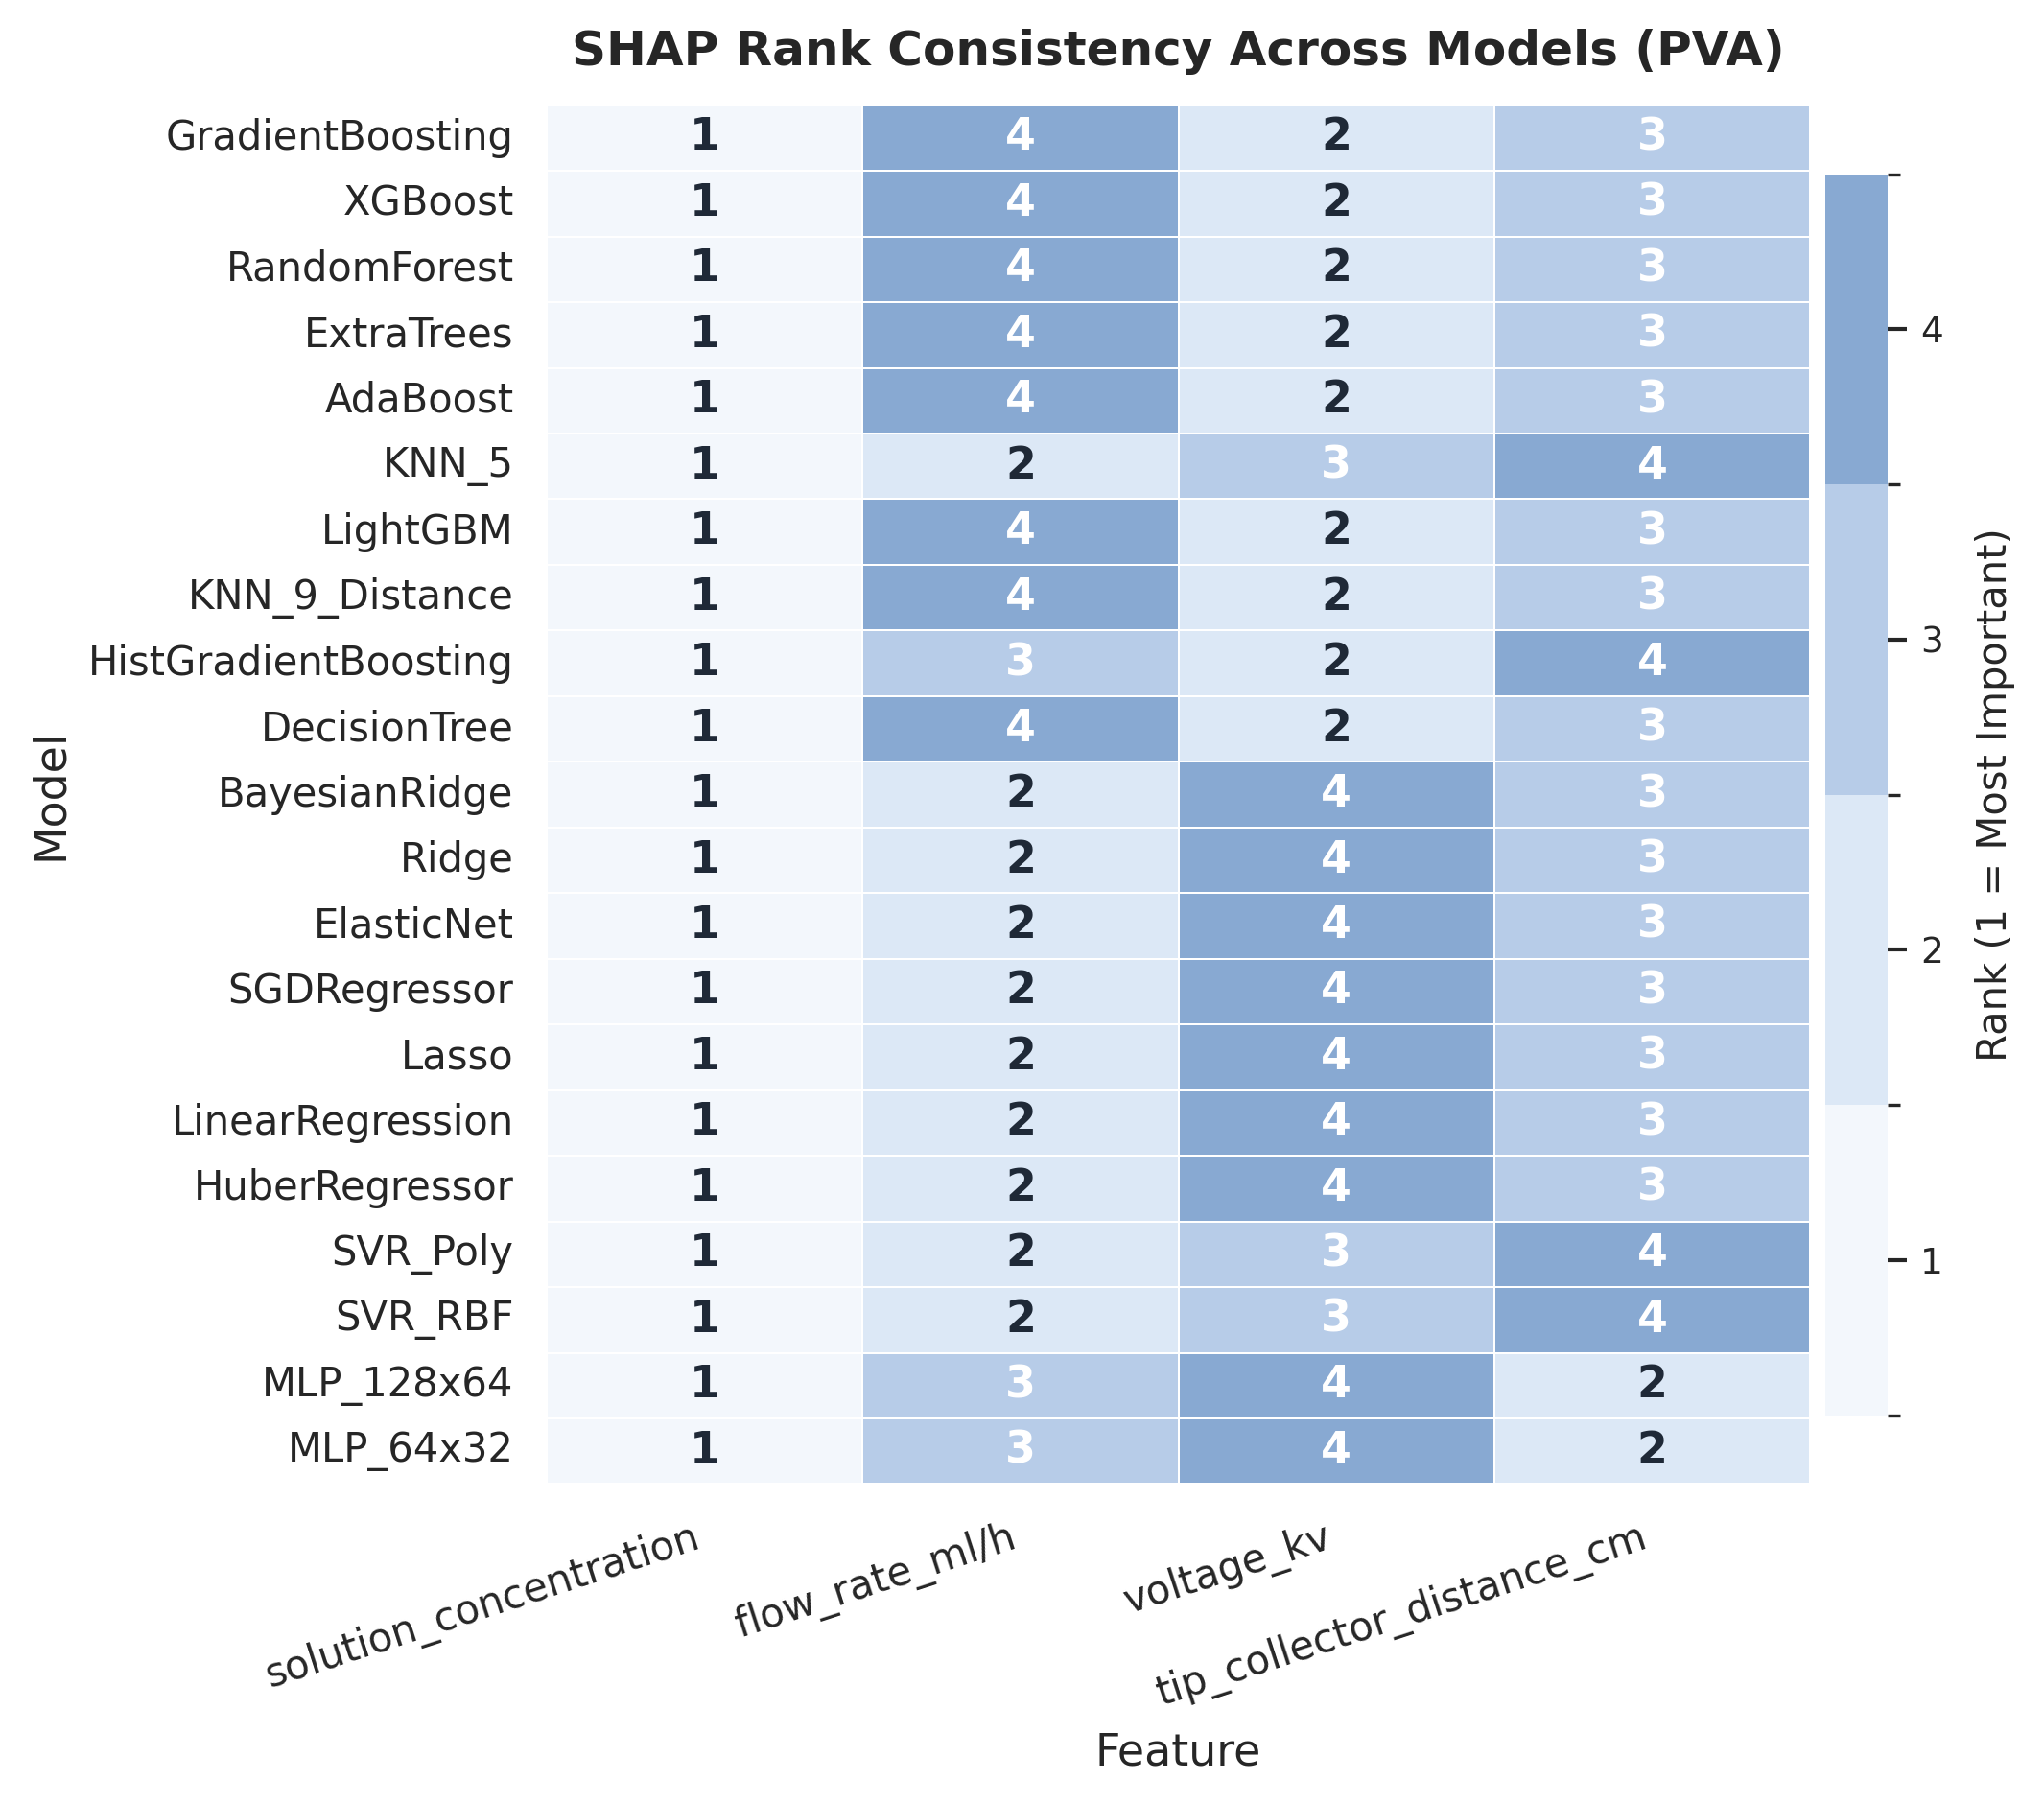

✓ Heatmap saved as PDF and PNG


In [26]:
# Create publication-ready heatmap
sns.set_theme(style="white", context="paper")
fig_w = 7.16  # IEEE 2-column full width
fig_h = 6.2
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=300)

# Discrete color palette for ranks
n_ranks = plot_matrix_t.max().max().astype(int)
bounds = np.arange(0.5, n_ranks + 1.5, 1)
norm = BoundaryNorm(bounds, ncolors=n_ranks)
soft_blue = ListedColormap(["#f3f7fc", "#dce8f6", "#b7cce8", "#88a9d2"][:n_ranks])

# Create heatmap
hm = sns.heatmap(
    plot_matrix_t,
    ax=ax,
    cmap=soft_blue,
    norm=norm,
    annot=True,
    fmt=".0f",
    annot_kws={"fontsize": 11, "fontweight": "semibold"},
    linewidths=0.4,
    linecolor="white",
    cbar=True,
    cbar_kws={"ticks": np.arange(1, n_ranks + 1), "shrink": 0.9, "pad": 0.01}
)

# Title and labels
ax.set_title(f"SHAP Rank Consistency Across Models ({system_for_shap})",
             fontsize=12, weight="bold", pad=10)
ax.set_xlabel("Feature", fontsize=11, labelpad=4)
ax.set_ylabel("Model", fontsize=11, labelpad=4)

# Tick formatting
ax.set_xticklabels(ax.get_xticklabels(), rotation=18, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# Improve text contrast
for txt in ax.texts:
    try:
        val = float(txt.get_text())
        txt.set_color("#1f2937" if val <= 2 else "#ffffff")
    except ValueError:
        continue

# Colorbar styling
cbar = hm.collections[0].colorbar
cbar.set_label("Rank (1 = Most Important)", rotation=90, labelpad=8, fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Remove spines for clean appearance
for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout(pad=0.5)
fig.savefig("fig_shap_rank_heatmap_ieee_2col_transposed.pdf", dpi=600, bbox_inches="tight", format="pdf")
fig.savefig("fig_shap_rank_heatmap_ieee_2col_transposed.png", dpi=600, bbox_inches="tight", format="png")
plt.show()

print("✓ Heatmap saved as PDF and PNG")

## 18. Validation and Leakage Diagnostics


In [27]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score

print("Validation diagnostics")
print("-" * 72)

# 1) Basic dataset checks
system_name = list(datasets.keys())[0]
X_val, y_val = datasets[system_name]
n_samples = len(X_val)

print(f"System: {system_name}")
print(f"Samples: {n_samples}, Features: {X_val.shape[1]}")
print(f"CV folds configured: {cv.get_n_splits()}")

if cv.get_n_splits() > n_samples:
    print("[FAIL] Number of CV folds is greater than sample count.")
else:
    min_fold_size = n_samples // cv.get_n_splits()
    print(f"[OK] Fold configuration is valid (min fold size ~= {min_fold_size}).")

# 2) Duplicate checks (potential split leakage if near-identical records are split)
dup_all = pd.concat([X_val, y_val.rename("fiber_diameter_nm")], axis=1).duplicated().sum()
dup_x = X_val.duplicated().sum()
print(f"Duplicate full rows (X+y): {dup_all}")
print(f"Duplicate feature rows (X only): {dup_x}")
if dup_x > 0:
    print("[WARN] Duplicate feature rows detected; fold-level leakage risk is elevated.")

# 3) Target-leakage proxy check via very high feature-target correlation
corr_abs = pd.concat([X_val, y_val.rename("fiber_diameter_nm")], axis=1).corr(numeric_only=True)["fiber_diameter_nm"].drop("fiber_diameter_nm").abs()
max_corr = corr_abs.max() if len(corr_abs) else np.nan
print(f"Max |feature-target correlation|: {max_corr:.3f}")
if np.isfinite(max_corr) and max_corr > 0.98:
    print("[WARN] Extremely high correlation suggests possible proxy leakage.")
else:
    print("[OK] No extreme single-feature proxy detected by correlation screen.")

# 4) Preprocessing leakage check: scaling should be inside pipeline for scale-sensitive models
scale_sensitive = {"LinearRegression", "Ridge", "Lasso", "ElasticNet", "BayesianRidge", "SGDRegressor", "HuberRegressor", "SVR_RBF", "SVR_Poly", "KNN_5", "KNN_9_Distance", "MLP_64x32", "MLP_128x64"}
missing_pipeline = []
for m in scale_sensitive:
    obj = models.get(m)
    if not isinstance(obj, Pipeline):
        missing_pipeline.append(m)
print(f"Scale-sensitive models checked: {len(scale_sensitive)}")
if missing_pipeline:
    print(f"[FAIL] Not wrapped in pipeline: {missing_pipeline}")
else:
    print("[OK] All scale-sensitive models are wrapped in per-fold pipelines.")

# 5) Overfitting gap check on top model
best_model_name = results_df.iloc[0]["Model"]
best_model = clone(models[best_model_name])

# Out-of-fold predictions (strict CV estimate)
oof_pred = cross_val_predict(best_model, X_val, y_val, cv=cv)
oof_r2 = r2_score(y_val, oof_pred)

# In-sample fit for gap estimation
best_model.fit(X_val, y_val)
train_r2 = r2_score(y_val, best_model.predict(X_val))
overfit_gap = train_r2 - oof_r2

print(f"Best model by CV mean R²: {best_model_name}")
print(f"OOF R²: {oof_r2:.3f}")
print(f"Train R²: {train_r2:.3f}")
print(f"Overfit gap (Train - OOF): {overfit_gap:.3f}")
if overfit_gap > 0.20:
    print("[WARN] Large overfit gap; model may be optimistic for unseen data.")
else:
    print("[OK] Overfit gap is within a moderate range.")

print("Validation diagnostics completed.")

Validation diagnostics
------------------------------------------------------------------------
System: PVA
Samples: 96, Features: 4
CV folds configured: 5
[OK] Fold configuration is valid (min fold size ~= 19).
Duplicate full rows (X+y): 0
Duplicate feature rows (X only): 0
Max |feature-target correlation|: 0.785
[OK] No extreme single-feature proxy detected by correlation screen.
Scale-sensitive models checked: 13
[OK] All scale-sensitive models are wrapped in per-fold pipelines.
Best model by CV mean R²: GradientBoosting
OOF R²: 0.906
Train R²: 0.982
Overfit gap (Train - OOF): 0.076
[OK] Overfit gap is within a moderate range.
Validation diagnostics completed.


In [28]:
# Robustness check: sensitivity to CV split randomness (top-5 models)
from sklearn.model_selection import KFold, cross_val_score

X_rb, y_rb = datasets[list(datasets.keys())[0]]
top5_models = results_df.head(5)["Model"].tolist()
seeds = [7, 21, 42, 84, 126]

robust_records = []
for model_name in top5_models:
    model_obj = models[model_name]
    r2_by_seed = []
    for seed in seeds:
        cv_seed = KFold(n_splits=5, shuffle=True, random_state=seed)
        scores = cross_val_score(model_obj, X_rb, y_rb, cv=cv_seed, scoring="r2")
        r2_by_seed.append(scores.mean())

    robust_records.append({
        "Model": model_name,
        "R2_mean_across_seeds": float(np.mean(r2_by_seed)),
        "R2_std_across_seeds": float(np.std(r2_by_seed, ddof=1)),
        "R2_min_seed": float(np.min(r2_by_seed)),
        "R2_max_seed": float(np.max(r2_by_seed)),
    })

robust_df = pd.DataFrame(robust_records).sort_values("R2_mean_across_seeds", ascending=False)
print("Robustness to CV random seed (Top-5 models)\n")
print(robust_df.to_string(index=False))

Robustness to CV random seed (Top-5 models)

           Model  R2_mean_across_seeds  R2_std_across_seeds  R2_min_seed  R2_max_seed
GradientBoosting                 0.904                0.016        0.884        0.926
         XGBoost                 0.886                0.020        0.863        0.911
    RandomForest                 0.839                0.038        0.783        0.869
      ExtraTrees                 0.812                0.039        0.760        0.842
        AdaBoost                 0.778                0.034        0.733        0.810
